<a href="https://colab.research.google.com/github/codezart/2024-new-grad-intern/blob/dev/explainable_extra_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from imblearn.over_sampling import SMOTE
import shap
import joblib
import os

ModuleNotFoundError: No module named 'imblearn'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path_to_dataset = "/content/drive/MyDrive/CSV_Files/"

In [ ]:
os.listdir(path_to_dataset)

['.DS_Store',
 'F0L.csv',
 'F0M.csv',
 'F1L.csv',
 'F1M.csv',
 'F2L.csv',
 'F2M.csv',
 'F3L.csv',
 'F3M.csv',
 'F4L.csv',
 'F4M.csv',
 'F5L.csv',
 'F5M.csv',
 'F6L.csv',
 'F6M.csv',
 'F7L.csv',
 'F7M.csv']

In [ ]:
all_data = []

for file in os.listdir(path_to_dataset):
    if file.endswith(".csv") and file.startswith("F"):
        df = pd.read_csv(path_to_dataset + file)

        fault = int(file[1])
        mode = file[2].upper()

        df['fault_type'] = fault
        df['is_mppt'] = 1 if mode == 'M' else 0
        df['is_ippt'] = 1 if mode == 'L' else 0

        all_data.append(df)

df = pd.concat(all_data, ignore_index=True)


In [ ]:
df.head()

,Time,Ipv,Vpv,Vdc,ia,ib,ic,va,vb,vc,Iabc,If,Vabc,Vf,fault_type,is_mppt,is_ippt
0,0.000028,1.572327,101.348877,144.140625,-0.135133,0.490112,-0.354985,41.744537,-149.872894,109.064585,1.0,50.0,1.0,50.0,0,0,1
1,0.000128,1.503265,101.458740,143.554688,-0.108277,0.510254,-0.388555,46.831512,-150.716705,105.829976,1.0,50.0,1.0,50.0,0,0,1
2,0.000228,1.492859,101.574707,143.554688,-0.168702,0.496826,-0.334844,51.074677,-152.018585,102.543132,1.0,50.0,1.0,50.0,0,0,1
3,0.000328,1.558136,101.312256,143.261719,-0.135133,0.510254,-0.361699,55.848236,-152.585144,98.143260,1.0,50.0,1.0,50.0,0,0,1
4,0.000428,1.631927,101.141357,143.847656,-0.202271,0.503540,-0.321416,60.055237,-152.609253,94.261729,1.0,50.0,1.0,50.0,0,0,1


In [ ]:
df.describe()

,Time,Ipv,Vpv,Vdc,ia,ib,ic,va,vb,vc,Iabc,If,Vabc,Vf,fault_type,is_mppt,is_ippt
count,2.163480e+06,2.163480e+06,2.163480e+06,2.163480e+06,2.163480e+06,2.163480e+06,2.163480e+06,2.163480e+06,2.163480e+06,2.163480e+06,2.163480e+06,2.163480e+06,2.163480e+06,2.163480e+06,2.163480e+06,2.163480e+06,2.163480e+06
mean,6.901942e+00,1.777343e+00,8.810269e+01,1.393910e+02,-2.103150e-02,1.563835e-03,-2.372308e-02,8.390207e-01,8.219660e-01,8.256761e-01,5.649684e-01,4.964643e+01,1.550879e+02,4.999965e+01,3.555546e+00,4.946050e-01,5.053950e-01
std,4.082440e+00,6.033849e-01,2.324239e+01,2.733158e+01,5.720828e-01,5.757026e-01,5.637509e-01,1.098731e+02,1.098750e+02,1.098609e+02,5.577446e-01,3.719884e+00,6.086033e+00,2.068362e-02,2.344306e+00,4.999710e-01,4.999710e-01
min,3.900159e-06,-5.950623e-01,-1.655884e+01,0.000000e+00,-6.358888e+00,-7.297974e+00,-1.285621e+01,-1.622046e+02,-1.622046e+02,-1.600348e+02,5.942768e-09,-2.225850e-02,1.000000e+00,4.944457e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.379926e+00,1.463531e+00,8.700562e+01,1.432617e+02,-3.835459e-01,-3.356934e-01,-3.482715e-01,-1.089963e+02,-1.090204e+02,-1.090565e+02,4.552899e-01,4.992011e+01,1.550905e+02,4.999663e+01,1.000000e+00,0.000000e+00,0.000000e+00
50%,6.759857e+00,1.791809e+00,9.131470e+01,1.444336e+02,-1.428320e-02,6.713867e-03,-3.271973e-02,8.438110e-01,8.076477e-01,7.835388e-01,4.943000e-01,5.000669e+01,1.553378e+02,5.000009e+01,4.000000e+00,0.000000e+00,1.000000e+00
75%,1.034940e+01,2.283752e+00,1.013977e+02,1.473633e+02,3.415518e-01,3.558350e-01,3.231152e-01,1.106960e+02,1.106839e+02,1.106598e+02,6.799564e-01,5.010295e+01,1.556174e+02,5.000350e+01,6.000000e+00,1.000000e+00,1.000000e+00
max,1.440000e+01,1.120874e+01,1.114746e+02,2.537109e+02,1.376929e+01,6.828003e+00,6.358882e+00,1.612041e+02,1.612041e+02,1.602116e+02,6.774100e+00,5.186277e+01,1.562917e+02,5.046424e+01,7.000000e+00,1.000000e+00,1.000000e+00


<Axes: >

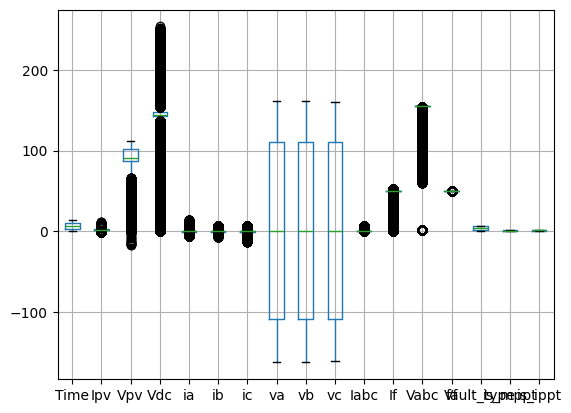

In [ ]:
df.boxplot()

In [ ]:
f

,0
Time,2163480
Ipv,2163480
Vpv,2163480
Vdc,2163480
ia,2163480
ib,2163480
ic,2163480
va,2163480
vb,2163480
vc,2163480


<Axes: xlabel='fault_type'>

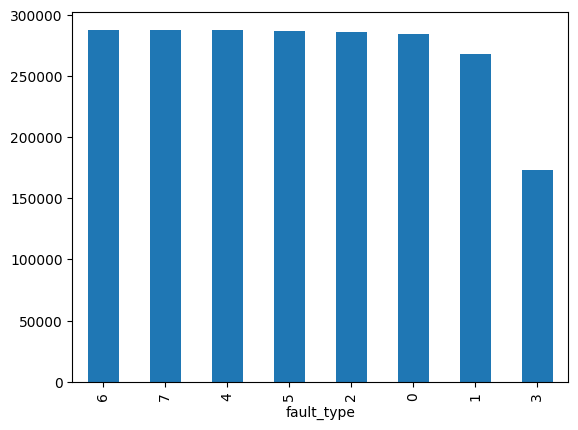

In [ ]:
df["fault_type"].value_counts().plot(kind="bar")

We have 2 classifiers:
1. Detector: Detects if there is a fault or no. 0 means no fault or healthy system. 1 means there was a fault
2. Diagnoser: Considering rows with faults (non healthy data), What type of fault it is. 1-7 types of faults

Short form for
1. Detector: det
2. Diagnoser: diag

In [ ]:
X  = df.drop('fault_type', axis=1)              #  m sensor features
y  = df['fault_type']                           #  0 = healthy, 1‑7 = fault classes


In [ ]:
y_detect = (y != 0).astype(int) # If not 0 ( not healthy) TRUE == 1, if healthy (0) FALSE = 0

In [ ]:
X_train, X_test, y_det_train, y_det_test = train_test_split(
        X, y_detect, test_size=0.2, stratify=y_detect, random_state=42) # applying seed 42 to keep things consistent. 80/20 split in data

In [ ]:
from imblearn.over_sampling import RandomOverSampler


In [ ]:

ros = RandomOverSampler(random_state=42)
X_train_det_rs, y_det_train_rs = ros.fit_resample(X_train, y_det_train)

In [ ]:
fault_mask = y != 0
X_fault = X[fault_mask]
y_fault = y[fault_mask]

# ensures only faults (1-7) data is preserved. We are leaving out the type 0 data here.

In [ ]:
X_f_train, X_f_test, y_f_train, y_f_test = train_test_split(
        X_fault, y_fault, test_size=0.2, stratify=y_fault, random_state=42) # applying seed 42 to keep things consistent. 80/20 split in data

ros = RandomOverSampler(random_state=42)
X_f_train_rs, y_f_train_rs = ros.fit_resample(X_f_train, y_f_train)


In [ ]:
# how many in X_f_test
y_f_test.count()

np.int64(375751)

In [ ]:
param_dist = {
    'n_estimators': [100],
    'max_depth': [None],
    'max_features': ['sqrt']
}
detector = RandomizedSearchCV(
    ExtraTreesClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=4,  # Try only 4 random combinations
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

diagnoser = RandomizedSearchCV(
    ExtraTreesClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=4,  # Again, 4 is much better than 18
    cv=3,
    scoring='f1_weighted',
    random_state=42
)


In [ ]:
detector.fit (X_train_det_rs, y_det_train_rs)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=4. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=ExtraTreesClassifier(class_weight='balanced',
                                                  n_jobs=-1, random_state=42),
                   n_iter=4, n_jobs=-1,
                   param_distributions={'max_depth': [None],
                                        'max_features': ['sqrt'],
                                        'n_estimators': [100]},
                   random_state=42, scoring='f1')

In [ ]:
# ---- phase 1
y_det_pred = detector.predict(X_test)
print('Detection  accuracy', accuracy_score (y_det_test, y_det_pred))
print('Detection  F1       ', f1_score       (y_det_test, y_det_pred))



Detection  accuracy 0.9983637472960231
Detection  F1        0.9990585456924477


In [ ]:
joblib.dump(detector.best_estimator_,   'et_detector.pkl')


['et_detector.pkl']

In [ ]:
diagnoser.fit(X_f_train_rs   , y_f_train_rs)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 1 is smaller than n_iter=4. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=ExtraTreesClassifier(class_weight='balanced',
                                                  n_jobs=-1, random_state=42),
                   n_iter=4,
                   param_distributions={'max_depth': [None],
                                        'max_features': ['sqrt'],
                                        'n_estimators': [100]},
                   random_state=42, scoring='f1_weighted')

In [ ]:
joblib.dump(diagnoser.best_estimator_, 'et_diagnoser.pkl')


['et_diagnoser.pkl']

In [ ]:
y.head()

,fault_type
0,0
1,0
2,0
3,0
4,0


In [ ]:
X_diag_test.index

Index([1610007, 1998276,  596178, 1602897, 1831966,  572902, 1685391,  294451,
        649296, 1995447,
       ...
        950554,  441175, 1091256,  561031,  430940, 2156802,  418661, 1041412,
        792600,  868202],
      dtype='int64', length=376278)

In [ ]:
# ---- phase 2 (only for rows the detector marked faulty)
# fault_rows  = y_det_pred == 1
# X_diag_test = X_test[fault_rows]
# print(fault_rows)
# y_true_diag = y.loc[y_f_test.index]

y_f_pred = diagnoser.predict(X_f_test)
print('Diagnosis accuracy', accuracy_score (y_f_test, y_f_pred))
print('Diagnosis macro‑F1', f1_score       (y_f_test, y_f_pred, average='macro'))


Diagnosis accuracy 0.9980625467397293
Diagnosis macro‑F1 0.9980149607645982


## Explainability

In [ ]:
# detector = joblib.load('et_detector.pkl')
diagnoser = joblib.load('et_diagnoser.pkl')

In [ ]:
y_f_pred = diagnoser.predict(X_f_test)
print('Diagnosis accuracy', accuracy_score (y_f_test, y_f_pred))
print('Diagnosis macro‑F1', f1_score       (y_f_test, y_f_pred, average='macro'))


Diagnosis accuracy 0.9980625467397293
Diagnosis macro‑F1 0.9980149607645982


In [ ]:

explainer = shap.TreeExplainer(diagnoser.best_estimator_)
shap_values = explainer.shap_values(X_f_test)

shap.summary_plot(shap_values, X_f_test, plot_type='bar')   # global ranking


NameError: name 'shap' is not defined

In [ ]:
joblib.dump(detector.best_estimator_,   'et_detector.pkl')
joblib.dump(diagnoser.best_estimator_, 'et_diagnoser.pkl')
